# 04 — Particle Swarm Optimization (PSO) Feature Selection

**Goal:** use PSO to search for the feature subset that maximizes classification
performance while minimizing the number of features used. PSO treats each candidate solution as a particle moving through search space, pulled toward its own best-known position and the swarm's best-known position.

This notebook follows the exact same pipeline as every other optimizer notebook in
this project (GA / PSO / GWO / WOA) — only the optimizer differs — so results are
directly comparable in `07_Comparison.ipynb`.

**Pipeline:**

```
Initialize swarm (particles = candidate feature masks)
        |
        v
  Evaluate fitness (via utils.fitness.fitness)
        |
        v
   Update personal best (pbest) per particle
        |
        v
   Update global best (gbest) across swarm
        |
        v
   Update velocity & position of each particle
        |
        v
   Repeat for `epoch` iterations
        |
        v
  Return best feature subset
```


In [1]:
import sys
sys.path.append("..")

import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.preprocessing import load_processed_data
from utils.metrics import evaluate_subset
from utils.fitness import make_fitness_fn

## 1. Load processed data (from notebook 01)

In [2]:
X_train, X_test, y_train, y_test, feature_names = load_processed_data("../datasets")
n_features = X_train.shape[1]
print("Number of features:", n_features)

Number of features: 30


## 2. Define the fitness function

`utils.fitness.fitness` is shared across ALL optimizer notebooks. It combines
classification error with a small penalty on the number of selected features.

In [3]:
fitness_fn = make_fitness_fn(
    X_train, X_test, y_train, y_test,
    classifier="svm",   # keep consistent with the baseline notebook
    alpha=0.99,
)

# mealpy expects fit_func(solution) -> float (to minimize)
def obj_func(solution):
    return fitness_fn(solution)

## 3. Configure and run PSO

Solutions are continuous vectors in [0, 1]^n_features; each dimension is
binarized (`>0.5` -> feature selected) inside the fitness function.

In [5]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def run_bpso(
    obj_func,
    n_features,
    pop_size=30,
    iterations=50,
    w=0.4,
    c1=2.05,
    c2=2.05,
):
    # Initialize particles
    positions = np.random.randint(0, 2, (pop_size, n_features))
    velocities = np.random.uniform(-1, 1, (pop_size, n_features))

    # Personal best
    pbest_positions = positions.copy()
    pbest_scores = np.array([obj_func(p) for p in positions])

    # Global best
    best_idx = np.argmin(pbest_scores)
    gbest_position = pbest_positions[best_idx].copy()
    gbest_score = pbest_scores[best_idx]

    convergence = []

    for _ in range(iterations):

        for i in range(pop_size):

            r1 = np.random.rand(n_features)
            r2 = np.random.rand(n_features)

            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (pbest_positions[i] - positions[i])
                + c2 * r2 * (gbest_position - positions[i])
            )

            probs = sigmoid(velocities[i])

            positions[i] = (np.random.rand(n_features) < probs).astype(int)

            # Prevent empty feature subset
            if positions[i].sum() == 0:
                positions[i, np.random.randint(n_features)] = 1

            score = obj_func(positions[i])

            if score < pbest_scores[i]:
                pbest_scores[i] = score
                pbest_positions[i] = positions[i].copy()

                if score < gbest_score:
                    gbest_score = score
                    gbest_position = positions[i].copy()

        convergence.append(gbest_score)

    return gbest_position, gbest_score, convergence

In [6]:
# PSO parameters
ITERATIONS = 50
POP_SIZE = 30

W = 0.4        # Inertia weight
C1 = 2.05      # Cognitive coefficient
C2 = 2.05      # Social coefficient

start_time = time.time()

best_position, best_fitness, convergence_curve = run_bpso(
    obj_func=fitness_fn,
    n_features=n_features,
    pop_size=POP_SIZE,
    iterations=ITERATIONS,
    w=W,
    c1=C1,
    c2=C2
)

runtime = time.time() - start_time

print(f"Best fitness: {best_fitness:.6f}")
print(f"Runtime: {runtime:.2f} seconds")

Best fitness: 0.012684
Runtime: 46.96 seconds


## 4. Extract convergence curve

Saved for the comparison plots in `07_Comparison.ipynb`.

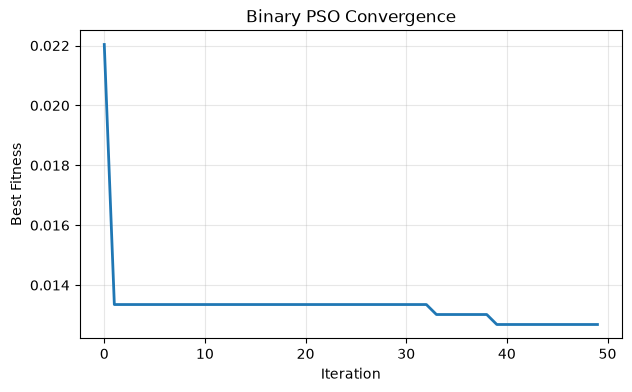

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(convergence_curve, linewidth=2)

plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("Binary PSO Convergence")

plt.grid(alpha=0.3)
plt.show()

## 5. Evaluate the best feature subset

Using the exact same `evaluate_subset()` function as the baseline notebook.

In [8]:
best_mask = best_position.astype(int)

selected_features = [
    f for f, m in zip(feature_names, best_mask)
    if m == 1
]

print(f"BPSO selected {best_mask.sum()} / {n_features} features:")
print(selected_features)

results = evaluate_subset(
    best_mask,
    X_train,
    X_test,
    y_train,
    y_test,
    classifier="svm"
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "n_features"]:
    print(f"{metric}: {results[metric]}")

BPSO selected 12 / 30 features:
['mean smoothness', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'compactness error', 'symmetry error', 'fractal dimension error', 'worst perimeter', 'worst smoothness', 'worst compactness', 'worst concavity']
accuracy: 0.9912280701754386
precision: 0.9863013698630136
recall: 1.0
f1: 0.993103448275862
roc_auc: 1.0
n_features: 12


## 6. Save results

Saved to `../results/pso_results.csv` and
`../results/pso_convergence.npy` for `07_Comparison.ipynb`.

In [9]:
import os
os.makedirs("../results", exist_ok=True)

results_df = pd.DataFrame([{
    "Algorithm": "PSO",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1": results["f1"],
    "ROC_AUC": results["roc_auc"],
    "Features": results["n_features"],
    "Runtime": runtime,
}])

results_df.to_csv("../results/pso_results.csv", index=False)
np.save("../results/pso_convergence.npy", np.array(convergence_curve))
np.save("../results/pso_mask.npy", best_mask)

results_df

,Algorithm,Accuracy,Precision,Recall,F1,ROC_AUC,Features,Runtime
0,PSO,0.991228,0.986301,1.0,0.993103,1.0,12,46.955686


## Next step

Run the remaining optimizer notebooks (any not yet run), then open
`07_Comparison.ipynb` to compare PSO against the baseline and the other
metaheuristics side by side.